### Genetic Algorithm

Proyek ini mengimplementasikan **Algoritma Genetika (Genetic Algorithm)** untuk menyelesaikan masalah pencarian rute perjalanan terpendek (*Traveling Salesperson Problem*).

### Studi Kasus & Konsep Dasar:
* **Cerita:** Kita adalah seorang kurir yang harus mengunjungi **5 kota berbeda** yang tersebar di atas peta koordinat, dan harus kembali lagi ke kota tempat awal keberangkatan.
* **Tujuan GA:** Mencari kombinasi rute kunjungan urutan kota terbaik agar **total jarak perjalanan sependek mungkin**, tanpa ada kota yang terlewat atau dikunjungi dua kali.
* **Permutation Encoding:** Solusi direpresentasikan sebagai urutan angka indeks kota (contoh: `[2, 4, 1, 3, 0]`), di mana setiap angka mewakili urutan kunjungan dan setiap kota wajib muncul tepat satu kali.

In [1]:
import random
import matplotlib.pyplot as plt

In [2]:
city_coordinates = {
    0: (0, 0),
    1: (2, 3),
    2: (5, 2),
    3: (6, 8),
    4: (1, 7)
}

num_cities = len(city_coordinates)
pop_size = 2
generations = 40
CR = 0.85
MR = 0.2
tournament_k = 2

### menghitung total distance

In [3]:
def calculate_total_distance(route):
    total_dist = 0
    for i in range(len(route)):
        city_a = route[i]
        city_b = route[(i + 1) % len(route)]
        coord_a = city_coordinates[city_a]
        coord_b = city_coordinates[city_b]
        
        #Euclidean distance
        dist = ((coord_a[0] - coord_b[0])**2 + (coord_a[1] - coord_b[1])**2)**0.5
        total_dist += dist
    return total_dist

### Menghitung Fitness

In [4]:
def calculate_fitness(route):
    distance = calculate_total_distance(route)
    return 1.0 / distance

### Populasi awal

In [5]:
def create_chromosome():
    route = list(range(num_cities))
    random.shuffle(route)
    return route

population = [create_chromosome() for _ in range(pop_size)]
print(population)

[[2, 0, 3, 1, 4], [4, 0, 3, 1, 2]]


### Tournament Selection

In [6]:
def tournament_selection(population, fitnesses):
    selected_indices = random.sample(range(len(population)), tournament_k)
    best_idx = selected_indices[0]

    for idx in selected_indices:
        if fitnesses[idx] > fitnesses[best_idx]:
            best_idx = idx
    return population[best_idx].copy()

### Ordered Crossover

In [7]:
def crossover(parent1, parent2):
    if random.random() < CR:
        start, end = sorted([random.randint(0, num_cities - 1), random.randint(0, num_cities - 1)])

        child1 = [-1] * num_cities
        child2 = [-1] * num_cities

        child1[start:end+1] = parent1[start:end+1]
        child2[start:end+1] = parent2[start:end+1]

        def fill_remaining(child, parent):
            current_pos = (end + 1) % num_cities
            for gene in parent:
                if gene not in child:
                    child[current_pos] = gene
                    current_pos = (current_pos + 1) % num_cities
            return child

            
        child1 = fill_remaining(child1, parent2)
        child2 = fill_remaining(child2, parent1)
        return child1, child2
    
    return parent1.copy(), parent2.copy()

### Mutation

In [8]:
def mutate(chromosome):
    mutated = chromosome.copy()
    if random.random() < MR:
        idx1, idx2 = random.sample(range(num_cities), 2)
        mutated[idx1], mutated[idx2] = mutated[idx2], mutated[idx1]
    return mutated

### main loop

In [9]:
best_distance_history = []
best_route_ever = None
best_distance_ever = float('inf')

for gen in range(generations):
    fitnesses = [calculate_fitness(ind) for ind in population]

    max_fit_idx = fitnesses.index(max(fitnesses))
    current_best_route = population[max_fit_idx]
    current_best_dist = calculate_total_distance(current_best_route)

    if current_best_dist < best_distance_ever:
        best_distance_ever = current_best_dist
        best_route_ever = current_best_route.copy()

    best_distance_history.append(current_best_dist)

    new_population = [best_route_ever.copy()]

    while len(new_population) < pop_size:
        p1 = tournament_selection(population, fitnesses)
        p2 = tournament_selection(population, fitnesses)

        c1, c2 = crossover(p1, p2)
        c1 = mutate(c1)
        c2 = mutate(c2)

        new_population.append(c1)
        if len(new_population) < pop_size:
            new_population.append(c2)

    population = new_population

HASIL AKHIR TSP
Jarak Terpendek Ditemukan: 25.02
Rute Terbaik (Urutan Kota): [4, 0, 1, 2, 3]


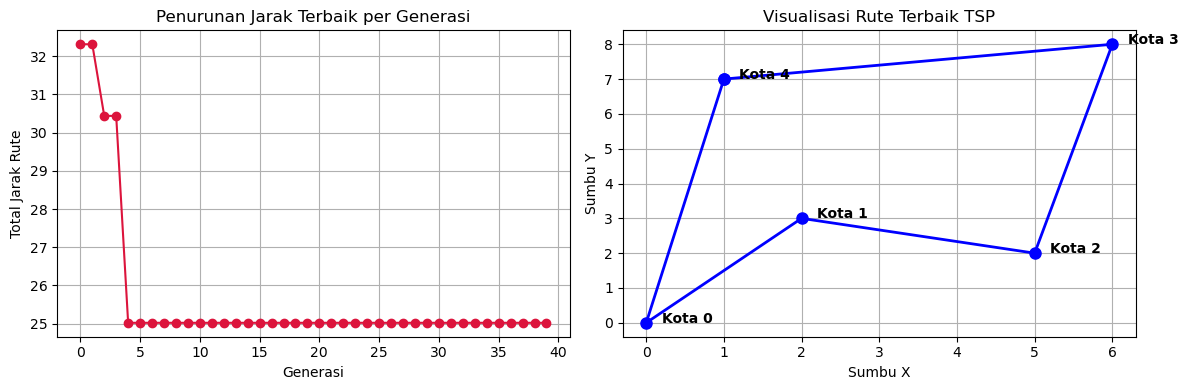

In [10]:
print("HASIL AKHIR TSP")
print(f"Jarak Terpendek Ditemukan: {best_distance_ever:.2f}")
print(f"Rute Terbaik (Urutan Kota): {best_route_ever}")

#VISUALISASI GRAFIK & PETA RUTE
plt.figure(figsize=(12, 4))

# Panel 1: Grafik penurunan jarak
plt.subplot(1, 2, 1)
plt.plot(best_distance_history, marker='o', color='crimson')
plt.title("Penurunan Jarak Terbaik per Generasi")
plt.xlabel("Generasi")
plt.ylabel("Total Jarak Rute")
plt.grid(True)

#Panel 2: Peta rute perjalanan kota terbaik
plt.subplot(1, 2, 2)
route_coords = [city_coordinates[city] for city in best_route_ever]
route_coords.append(city_coordinates[best_route_ever[0]]) # Kembali ke kota awal

x_coords = [coord[0] for coord in route_coords]
y_coords = [coord[1] for coord in route_coords]

plt.plot(x_coords, y_coords, marker='o', color='blue', linestyle='-', linewidth=2, markersize=8)
for city_id, coord in city_coordinates.items():
    plt.text(coord[0] + 0.2, coord[1], f"Kota {city_id}", fontsize=10, fontweight='bold')

plt.title("Visualisasi Rute Terbaik TSP")
plt.xlabel("Sumbu X")
plt.ylabel("Sumbu Y")
plt.grid(True)

plt.tight_layout()
plt.show()